In [1]:
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.visualization
import named_arrays as na
import ctis

In [2]:
wavelength_center = 171 * u.AA

In [3]:
wavelength = na.linspace(-500, 500, axis="wavelength", num=21) * u.km / u.s

In [4]:
position_scene = na.Cartesian2dVectorLinearSpace(
    start=-10 * u.arcsec,
    stop=10 * u.arcsec,
    axis=na.Cartesian2dVectorArray("fx", "fy"),
    num=128,
)

In [5]:
position_sensor = na.Cartesian2dVectorArray(
    x=na.arange(0, 256, axis="sx") * u.pix,
    y=na.arange(0, 128, axis="sy") * u.pix,
)

In [6]:
coordinates_scene = na.SpectralPositionalVectorArray(wavelength, position_scene)
coordinates_sensor = na.SpectralPositionalVectorArray(wavelength, position_sensor)

In [7]:
instrument = ctis.instruments.IdealInstrument(
    response=1,
    plate_scale=1 * u.arcsec / u.pix,
    dispersion=10 * u.km / u.s / u.pix,
    angle=0*u.deg,
    wavelength_ref=0 * u.km / u.s,
    position_ref=128 * u.pix,
    coordinates_scene=coordinates_scene,
    coordinates_sensor=coordinates_sensor,
    axis_scene_xy=("fx", "fy"),
    axis_sensor_xy=("sx", "sy"),
)

In [8]:
scene = ctis.scenes.gaussians(
    inputs=coordinates_scene,
    width=na.SpectralPositionalVectorArray(30 * u.km / u.s, 1 * u.arcsec),
)

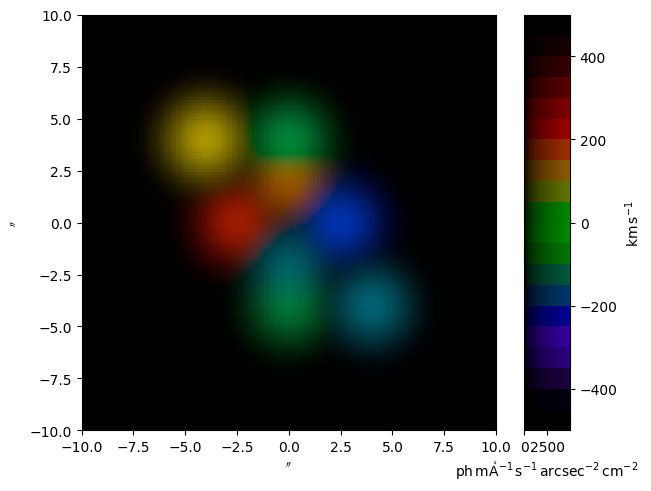

In [9]:
with astropy.visualization.quantity_support():
    fig, axs = plt.subplots(
        ncols=2,
        gridspec_kw=dict(width_ratios=[.9,.1]),
        constrained_layout=True,
    )
    colorbar = na.plt.rgbmesh(
        C=scene,
        axis_wavelength="wavelength",
        ax=axs[0],
        vmin=0,
        vmax=scene.outputs.max(),
    )
    na.plt.pcolormesh(
        C=colorbar,
        axis_rgb="wavelength",
        ax=axs[1],
    )
    axs[1].yaxis.tick_right()
    axs[1].yaxis.set_label_position("right")

In [10]:
image = instrument.image(scene)

axis_input=(1, 2)
axis_output=(1, 2)
axis_input=(np.int64(-1), np.int64(-2))
axis_output=(np.int64(-1), np.int64(-2))
axis_output_orthogonal=(np.int64(-3),)
shape_orthogonal=(21,)
ax=np.int64(-2)
ax=np.int64(-1)
shape_output=(256, 21, 128)


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (21,128,128)  and requested shape (128,21,128)

In [ ]:
image.shape